In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
VOCAB_SIZE = 10000
MAXLEN     = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Sample review    : {X_train[0][:20]} ...")
print(f"Label            : {y_train[0]}")

Training samples : 25000
Testing samples  : 25000
Sample review    : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...
Label            : 1


In [ ]:
X_train = pad_sequences(X_train, maxlen=MAXLEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAXLEN, padding='post', truncating='post')

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

X_train shape : (25000, 200)
X_test shape  : (25000, 200)


In [ ]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAXLEN),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5353 - loss: 0.6864 - val_accuracy: 0.5896 - val_loss: 0.6691
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6001 - loss: 0.6563 - val_accuracy: 0.6182 - val_loss: 0.6280
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6157 - loss: 0.6154 - val_accuracy: 0.7344 - val_loss: 0.5754
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7526 - loss: 0.5222 - val_accuracy: 0.7580 - val_loss: 0.5291
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8548 - loss: 0.3587 - val_accuracy: 0.8294 - val_loss: 0.4133


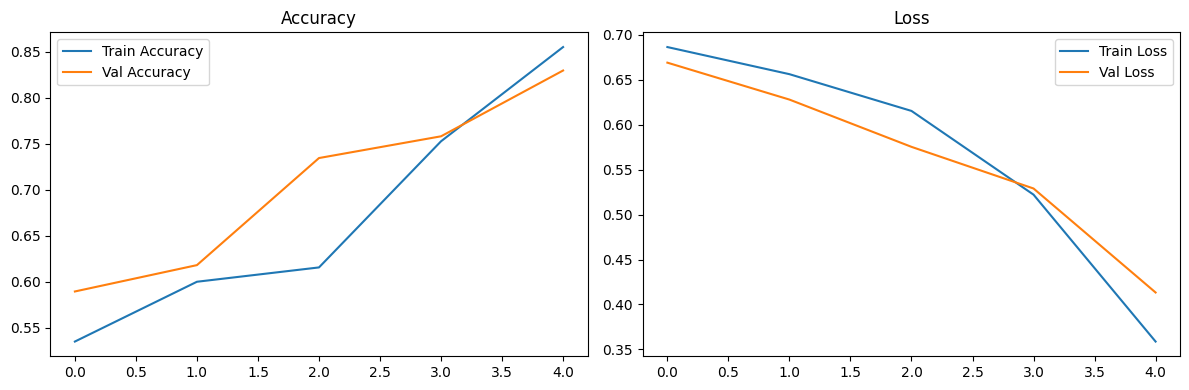

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Loss     : 0.4435
Test Accuracy : 81.47%


In [ ]:
sample   = X_test[0].reshape(1, -1)
pred_prob = model.predict(sample)[0][0]
sentiment = 'Positive :' if pred_prob >= 0.5 else 'Negative :'

print(f"Predicted Probability : {pred_prob:.4f}")
print(f"Predicted Sentiment   : {sentiment}")
print(f"Actual Label          : {'Positive :' if y_test[0] == 1 else 'Negative :  '}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Predicted Probability : 0.0783
Predicted Sentiment   : Negative :
Actual Label          : Negative :


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


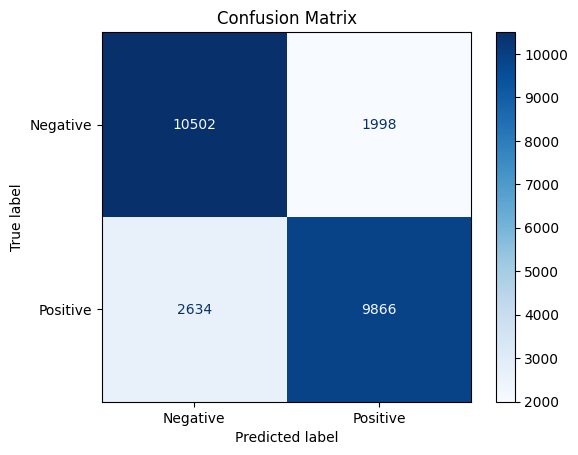

              precision    recall  f1-score   support

    Negative       0.80      0.84      0.82     12500
    Positive       0.83      0.79      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.82      0.81      0.81     25000
weighted avg       0.82      0.81      0.81     25000



In [ ]:
y_pred = (model.predict(X_test) >= 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))